# 머신러닝 프로젝트 진행 과정
## 04 머신러닝 기초 I

**학습 목표**: scikit-learn을 활용하여 실제 머신러닝 프로젝트 전체 흐름을 경험한다.

**사용 데이터셋**
- 회귀(Regression): `seaborn` 내장 **tips** 데이터셋
- 분류(Classification): `seaborn` 내장 **titanic** 데이터셋

**목차**
1. 머신러닝 프로젝트 진행 과정
2. 탐색적 데이터 분석 (EDA)
3. 결측치 처리
4. 이상치 처리
5. 특성 엔지니어링
6. 상관관계 분석
7. 모델 학습 및 평가


In [ ]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

---
## 0. 환경 설정

머신러닝 프로젝트에 필요한 라이브러리를 불러옵니다.

| 라이브러리 | 주요 용도 |
|-----------|---------|
| `numpy` | 수치 연산, 배열 처리 |
| `pandas` | 데이터프레임 조작, 전처리 |
| `matplotlib` | 기본 시각화 |
| `seaborn` | 통계 시각화 및 내장 데이터셋 |
| `sklearn` | 머신러닝 모델, 전처리, 평가 |


In [ ]:
# ── 기본 라이브러리 ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── scikit-learn ───────────────────────────────────────────────────────────
# KFold 교차검증 내용
# KFold + cross_val_score (평가지표)
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# LabelEncoder : 범주형을 숫자로 변환
# - 종속변수에서만 활용
# - 생존, 사망 => 1, 0으로 변환
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 선형 모델
from sklearn.linear_model import LinearRegression, LogisticRegression

# 트리 모델, RandomFrest 모델
# - 2010년대 중반까지는 많이 사용되었던 모델
# - XGBoost, CatBoost, LightGBM 모델이 좀 더 성능이 나아짐
# -- 핵심원리 : 경사하강법
# 모델 선정 시 유의성 : 귀납적으로 유추
# - 여러 후보군 중에서 가장 좋은 모델 선택하는 훈련
# - 확률적으로는 XGBoost, CatBoost, LightGBM 중 1개가 선택될 가능성이 높음
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
 mean_squared_error, r2_score,
 accuracy_score, classification_report, confusion_matrix
)

# ══════════════════════════════════════════════════════════════════════════════
# 한글 폰트 설정 (NanumBarunGothic)
# ══════════════════════════════════════════════════════════════════════════════
# 1) 나눔 폰트 디렉터리에서 .ttf 파일을 모두 찾아 matplotlib 캐시에 등록
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
 fm.fontManager.addfont(ff)

# 2) matplotlib rcParams 전역 적용
plt.rcParams.update({
 'font.family' : 'NanumBarunGothic', # 한글 폰트
 'axes.unicode_minus': False, # 마이너스(-) 기호 깨짐 방지
 'axes.spines.top' : False,
 'axes.spines.right' : False,
 'axes.grid' : True,
 'grid.alpha' : 0.3,
 'figure.dpi' : 110,
})

# 3) seaborn 테마에도 동일하게 적용
# - font= : seaborn 내부 폰트 지정
# - rc={} : set_theme() 호출 시 rcParams가 리셋되므로
# rc 딕셔너리로 한글 폰트를 함께 전달해야 덮어씌워지지 않음
sns.set_theme(
 style='whitegrid',
 palette='muted',
 font='NanumBarunGothic',
 rc={
 'font.family' : 'NanumBarunGothic',
 'axes.unicode_minus': False,
 'axes.spines.top' : False,
 'axes.spines.right' : False,
 'axes.grid' : True,
 'grid.alpha' : 0.3,
 'figure.dpi' : 110,
 }
)

# ── 재현성을 위한 랜덤 시드 고정 ──────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" 라이브러리 로드 완료")
print(f" numpy : {np.__version__}")
print(f" pandas : {pd.__version__}")
print(f" seaborn: {sns.__version__}")
print(f" 폰트 : NanumBarunGothic")

 라이브러리 로드 완료
 numpy : 2.0.2
 pandas : 2.2.2
 seaborn: 0.13.2
 폰트 : NanumBarunGothic


---
## 1. 머신러닝 프로젝트 진행 과정

머신러닝 프로젝트는 크게 **데이터 분석**과 **머신러닝** 두 단계로 나뉩니다.

### 데이터 분석 단계
1. **데이터 수집** → 고품질 데이터를 수집해야 신뢰할 수 있는 모델을 만들 수 있음
2. **EDA (탐색적 데이터 분석)** → 데이터의 특성과 패턴을 이해
3. **모델 선택** → EDA 결과를 바탕으로 어떤 머신러닝 모델을 사용할지 결정

### 머신러닝 단계
4. **데이터 전처리** → 선택한 모델에 적합한 형태로 데이터 가공
5. **모델 학습** → 데이터의 패턴을 학습하여 예측 성능을 높이는 과정
6. **평가 및 예측** → 학습된 모델의 신뢰성 확인, 약점 파악 및 개선

> **과적합(Overfitting)**: 모델이 학습 데이터에 과하게 학습된 현상
> 학습 정확도는 높지만 테스트 정확도가 낮으면 과적합을 의심해야 합니다.


---
## 2. 탐색적 데이터 분석 (EDA)

EDA는 **가설 검증이나 모형을 적용하기 전에 데이터 스스로에 대한 정보를 전달**하도록 만드는 방법입니다.

### EDA 과정
1. **데이터 확인** → 변수 자료형, 크기, Raw data 파악 (평균, 최빈값, 중간값 등)
2. **데이터 정제** → 결측치 처리, 이상치 처리
3. **특성 엔지니어링** → 스케일링, 바이닝, 더미 변환

### 사용 함수
- `.info()` → 변수의 데이터 타입과 개수를 확인
- `.shape` → 데이터 전체 크기를 확인
- `.head()` → 데이터의 상위 5개 행 출력
- `.tail()` → 데이터의 하위 5개 행 출력
- `.describe()` → 수치형 변수의 기술통계량 요약


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# [회귀] tips 데이터셋 로드 및 기본 확인
# ══════════════════════════════════════════════════════════════════════════════

# seaborn 내장 데이터셋 'tips' 불러오기
# tips: 레스토랑에서 고객이 남긴 팁 데이터 (244건)
# 목표: total_bill(총 계산서 금액)을 이용해 tip(팁 금액) 예측 (회귀)
tips = sns.load_dataset("tips")

print("=" * 50)
print("[회귀] tips 데이터셋")
print("=" * 50)

# shape: (행 수, 열 수) 반환
print(f"\n 데이터 크기: {tips.shape}")

# info(): 각 컬럼의 데이터 타입과 결측치 수를 한 번에 확인
print("\n 데이터 정보 (.info()):")
tips.info()

[회귀] tips 데이터셋

 데이터 크기: (244, 7)

 데이터 정보 (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
# head(): 상위 5개 행 출력 → 실제 데이터 모양 확인
print(" 상위 5개 행 (.head()):")
display(tips.head())

# describe(): 수치형 변수의 기술통계량 (개수, 평균, 표준편차, 분위수 등)
print("\n 기술통계량 (.describe()):")
display(tips.describe())


 상위 5개 행 (.head()):


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



 기술통계량 (.describe()):


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# [분류] titanic 데이터셋 로드 및 기본 확인
# ══════════════════════════════════════════════════════════════════════════════

# seaborn 내장 데이터셋 'titanic' 불러오기
# titanic: 타이타닉 승객 생존 여부 데이터 (891건)
# 목표: 승객 정보를 이용해 survived(생존 여부) 예측 (분류)
titanic = sns.load_dataset('titanic')

print("=" * 50)
print("[분류] titanic 데이터셋")
print("=" * 50)
print(f"\n 데이터 크기: {titanic.shape}")
print("\n 데이터 정보 (.info()):")
titanic.info()

[분류] titanic 데이터셋

 데이터 크기: (891, 15)

 데이터 정보 (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
print(" 상위 5개 행 (.head()):")
display(titanic.head())

print("\n 기술통계량 (.describe()):")
display(titanic.describe())


 상위 5개 행 (.head()):


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



 기술통계량 (.describe()):


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- 시각화 작성 시 기본 원칙
  + 종속변수 위주로 시각화 작성
  + 회귀모델 목표
    - y : 수치데이터 (산점도, 박스플롯이 기본)
  + 분류모델 목표
    - y : 범주데이터 (막대 그래프, 빈도와 관련된 그래프가 우선 순위)
- 분포 (패턴이 발견되는가?)
- 목표
  + 머신러닝 전략 수립을 하기 위해서 EDA
    - 분포가 왜곡되어 있음 => 극단값에 영향을 받는다 => 선형모델?
      + 선형모델 => 표준화, 로그변환 사전에 이런 부분 처리
    - 사망 vs 생존의 개수가 1:1 구조가 아님 => 샘플링 문제 발생 가능성이 생김
      + 샘플링부터 고민 (클래스 불균형)
  + 시각화를 통해서 **패턴**을 발견하기 위해 노력

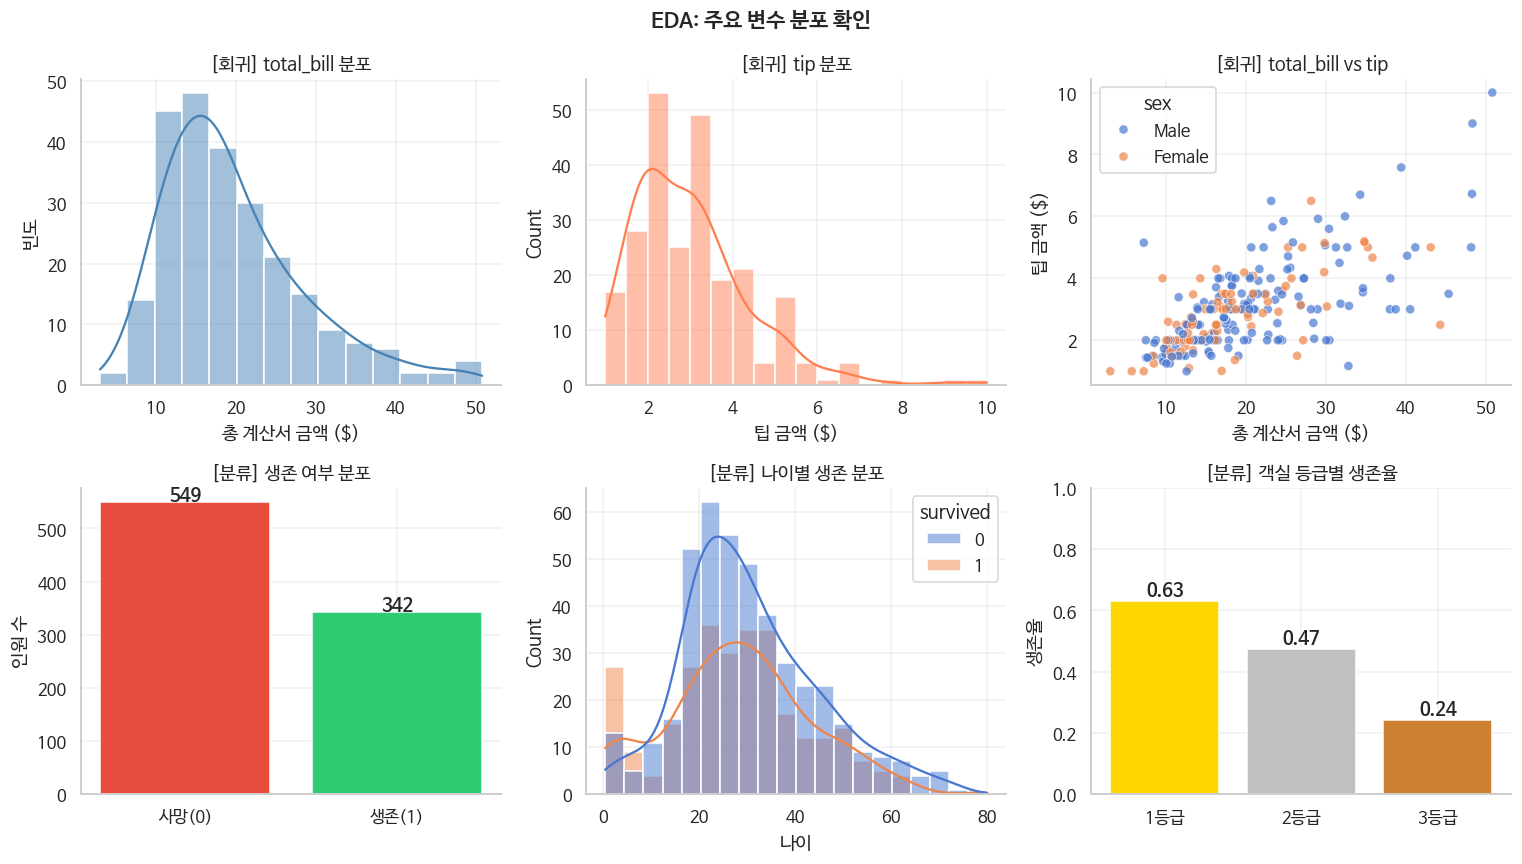

In [ ]:
# ── EDA 시각화: 두 데이터셋 주요 변수 분포 확인 ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('EDA: 주요 변수 분포 확인', fontsize=14, fontweight='bold')

# ── [회귀] tips 데이터셋 ───────────────────────────────────────────────────
# 1) total_bill 분포 (히스토그램 + KDE)
sns.histplot(data=tips, x='total_bill', kde=True,
             ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('[회귀] total_bill 분포')
axes[0, 0].set_xlabel('총 계산서 금액 ($)')
axes[0, 0].set_ylabel('빈도')

# 2) tip 분포
sns.histplot(data=tips, x='tip', kde=True,
             ax=axes[0, 1], color='coral')
axes[0, 1].set_title('[회귀] tip 분포')
axes[0, 1].set_xlabel('팁 금액 ($)')

# 3) total_bill vs tip 산점도 (목표 변수와의 관계 파악)
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='sex', ax=axes[0, 2], alpha=0.7)
axes[0, 2].set_title('[회귀] total_bill vs tip')
axes[0, 2].set_xlabel('총 계산서 금액 ($)')
axes[0, 2].set_ylabel('팁 금액 ($)')

# ── [분류] titanic 데이터셋 ───────────────────────────────────────────────
# 4) 생존 여부 비율 (분류 문제의 클래스 불균형 확인)
survived_counts = titanic['survived'].value_counts()
axes[1, 0].bar(['사망(0)', '생존(1)'], survived_counts.values,
               color=['#e74c3c', '#2ecc71'])
axes[1, 0].set_title('[분류] 생존 여부 분포')
axes[1, 0].set_ylabel('인원 수')
# 각 막대 위에 수치 표시
for i, v in enumerate(survived_counts.values):
    axes[1, 0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# 5) 나이 분포
sns.histplot(data=titanic, x='age', kde=True,
             hue='survived', ax=axes[1, 1])
axes[1, 1].set_title('[분류] 나이별 생존 분포')
axes[1, 1].set_xlabel('나이')

# 6) 객실 등급별 생존율 (범주형 변수 탐색)
pclass_survival = titanic.groupby('pclass')['survived'].mean()
axes[1, 2].bar(['1등급', '2등급', '3등급'], pclass_survival.values,
               color=['gold', 'silver', '#cd7f32'])
axes[1, 2].set_title('[분류] 객실 등급별 생존율')
axes[1, 2].set_ylabel('생존율')
axes[1, 2].set_ylim(0, 1)
for i, v in enumerate(pclass_survival.values):
    axes[1, 2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 3. 결측치 처리

**결측치(Missing Value)**: 데이터세트에서 누락된 값

- 데이터 수집 과정에서 발생할 수 있음
- 머신러닝 **모델의 성능에 부정적인 영향**을 줌

### 결측치 확인
- `isnull()` → DataFrame 내의 결측치를 bool 형식으로 반환
- `isnull().sum()` → 각 변수의 결측치 개수 반환

### 결측치 처리 방법

| 방법 | 설명 | 적합한 상황 |
|------|------|------------|
| **전체 삭제 (열 삭제)** | `.drop(['컬럼명'], axis=columns)` | 결측치가 매우 많은 열 |
| **부분 삭제 (행 삭제)** | `.dropna()` | 데이터가 많고 결측치가 적은 경우 |
| **일괄 대체** | `.fillna(평균/최빈값/중간값)` | 데이터가 적은 경우 |
| **유사 유형 대체** | 머신러닝으로 결측치 예측 | 정교한 처리가 필요한 경우 |


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 결측치 확인
# ══════════════════════════════════════════════════════════════════════════════

# titanic 데이터 복사본 생성 (원본 보존)
df_titanic = titanic.copy()

# isnull().sum(): 각 컬럼별 결측치 개수 반환
missing = df_titanic.isnull().sum()
missing_pct = (missing / len(df_titanic) * 100).round(2)  # 결측치 비율
# print(missing)

# 결측치가 있는 컬럼만 출력
# 컬럼명 : 결측치 수, 결측치 비율(%)
# pd.DataFrame()
missing_df = pd.DataFrame({
    '결측치 수' : missing,
    '결측치 비율(%)' : missing_pct
}).query('`결측치 수` > 0')  # 결측치가 1개 이상인 행만 필터링

print("[titanic] 결측치 현황:")
display(missing_df)


[titanic] 결측치 현황:


,결측치 수,결측치 비율(%)
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [ ]:
# df_titanic.drop(['deck'], axis='columns', inplace=True)
# 위 코드를 2번 이상 실행하면 아래와 같은 에러 발생
# KeyError: "['deck'] not found in axis"

In [ ]:
# 강사가 좋아하는 코드
# df_titanic2 = df_titanic.drop(['deck'], axis='columns').copy()
# df_titanic2.head(1)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 결측치 처리 적용
# ══════════════════════════════════════════════════════════════════════════════

# ── 1) 전체 삭제: 'deck' 열 → 결측치 비율 77%로 매우 높아 열 전체 제거 ─────
# inplace=True: 원본 DataFrame을 직접 수정 (새 변수에 할당하지 않아도 됨)
df_titanic.drop(['deck'], axis='columns', inplace=True)
print(" 'deck' 열 삭제 완료")

# ── 2) 부분 삭제: 'embark_town', 'embarked' → 결측치 2개뿐이므로 행 삭제 ──
df_titanic.dropna(subset=['embark_town', 'embarked'], inplace=True)
print(f" 'embarked', 'embark_town' 결측치 행 삭제: {891 - len(df_titanic)}행 제거")


 'deck' 열 삭제 완료
 'embarked', 'embark_town' 결측치 행 삭제: 2행 제거


In [ ]:
# ── 3) 일괄 대체: 'age' → 중간값으로 대체 ─────────────────────────────────
# 중간값을 사용하는 이유: 이상치에 덜 민감하여 나이처럼 분포가 치우친 변수에 적합
age_median = df_titanic['age'].median()
df_titanic['age'] = df_titanic['age'].fillna(age_median)

print(f" 'age' 결측치를 중간값({age_median})으로 대체 완료")

# 처리 후 결측치 확인
print(f"\n 처리 후 결측치 합계: {df_titanic.isnull().sum().sum()}개")
print(f" 최종 데이터 크기: {df_titanic.shape}")


 'age' 결측치를 중간값(28.0)으로 대체 완료

 처리 후 결측치 합계: 0개
 최종 데이터 크기: (889, 14)


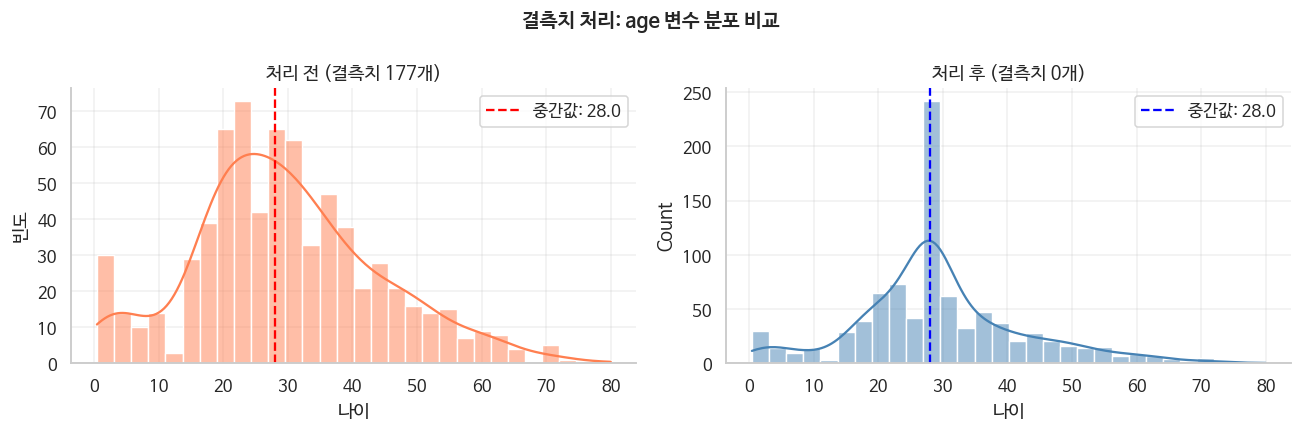

In [ ]:
# ── 결측치 처리 전/후 시각화 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('결측치 처리: age 변수 분포 비교', fontsize=13, fontweight='bold')

# 처리 전: 결측치가 있는 원본 데이터
sns.histplot(data=titanic, x='age', kde=True, ax=axes[0],
             color='coral', bins=30)
axes[0].set_title(f'처리 전 (결측치 {titanic["age"].isnull().sum()}개)')
axes[0].set_xlabel('나이')
axes[0].set_ylabel('빈도')
axes[0].axvline(titanic['age'].median(), color='red', linestyle='--',
                label=f'중간값: {titanic["age"].median():.1f}')
axes[0].legend()

# 처리 후: 중간값으로 채운 데이터
sns.histplot(data=df_titanic, x='age', kde=True, ax=axes[1],
             color='steelblue', bins=30)
axes[1].set_title(f'처리 후 (결측치 {df_titanic["age"].isnull().sum()}개)')
axes[1].set_xlabel('나이')
axes[1].axvline(df_titanic['age'].median(), color='blue', linestyle='--',
                label=f'중간값: {df_titanic["age"].median():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 4. 이상치 처리

**이상치(Outlier)**: 데이터세트에서 다른 데이터 포인트와 크게 벗어난 값

- 데이터 수집 과정에서 발생할 수 있음
- 머신러닝 **모델을 왜곡**할 수 있음
- 이상치를 판단하는 기준은 여러 가지가 있음

### 이상치 확인 방법
- **시각화**: `boxplot`, `histogram` → 분포를 보고 이상치 식별
- **IQR 방법**: 사분위수 범위(IQR = Q3 - Q1)를 이용한 기준

$$\text{이상치} = x < Q1 - 1.5 \times IQR \quad \text{or} \quad x > Q3 + 1.5 \times IQR$$

### 이상치 처리 방법

| 방법 | 설명 |
|------|------|
| **단순 삭제** | 이상치가 Human error로 발생한 경우 |
| **대체** | 데이터가 적어 삭제 불가 시 중앙값 등으로 대체 |
| **변수화** | 이상치가 자연 발생 & 의미 있는 정보를 담을 때 변수화 |


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 이상치 확인: IQR 방법
# ══════════════════════════════════════════════════════════════════════════════

# tips 데이터셋의 'total_bill' 변수에서 이상치 확인
df_tips = tips.copy() # 원본 보존

# IQR(사분위수 범위) 계산
Q1 = df_tips['total_bill'].quantile(0.25) # 1사분위수 (하위 25%)
Q3 = df_tips['total_bill'].quantile(0.75) # 3사분위수 (상위 75%)
IQR = Q3 - Q1

# 이상치 경계값 계산
# 도메인 지식에 입각해서 한 번 더 검토
lower_bound = Q1 - 1.5 * IQR  # 하한선
upper_bound = Q3 + 1.5 * IQR  # 상한선

print(f"[tips] total_bill 이상치 분석 (IQR 방법)")
print(f" Q1 (25%): {Q1:.2f}")
print(f" Q3 (75%): {Q3:.2f}")
print(f" IQR : {IQR:.2f}")
print(f" 하한선 : {lower_bound:.2f}")
print(f" 상한선 : {upper_bound:.2f}")

# 이상치 해당하는 행 필터링
outliers = df_tips.loc[
    (df_tips['total_bill'] < lower_bound) |
    (df_tips['total_bill'] > upper_bound),
    :]

print(f"\n 이상치 개수: {len(outliers)}개 ({len(outliers)/len(df_tips)*100:.1f}%)")
display(outliers[['total_bill', 'tip', 'size']].head())


[tips] total_bill 이상치 분석 (IQR 방법)
 Q1 (25%): 13.35
 Q3 (75%): 24.13
 IQR : 10.78
 하한선 : -2.82
 상한선 : 40.30

 이상치 개수: 9개 (3.7%)


,total_bill,tip,size
59,48.27,6.73,4
102,44.30,2.50,3
142,41.19,5.00,5
156,48.17,5.00,6
170,50.81,10.00,3


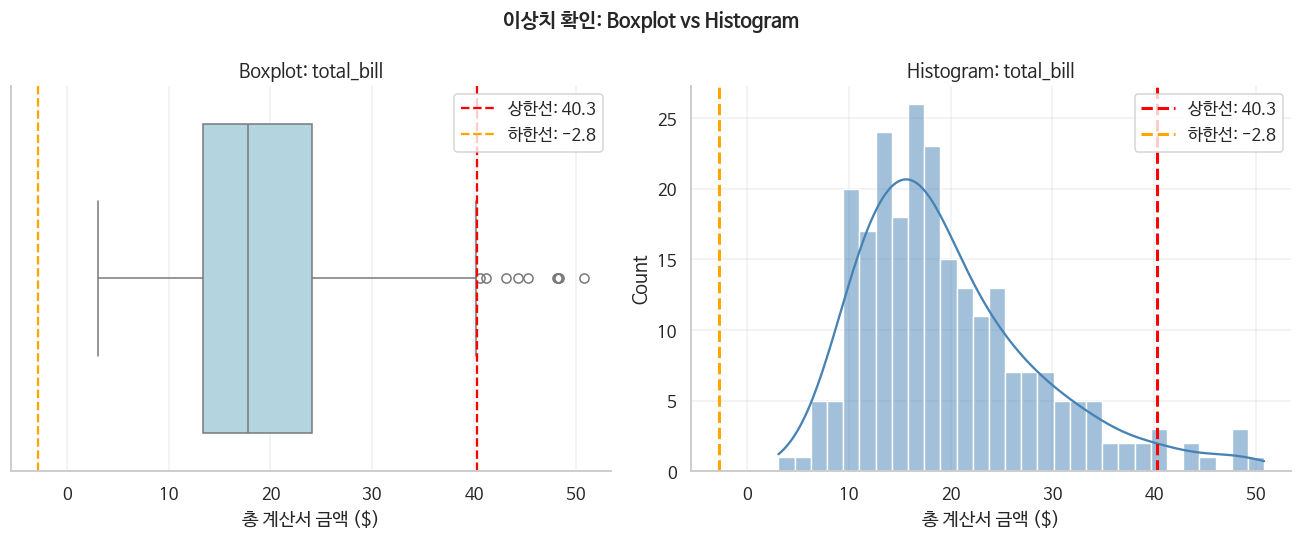

In [ ]:
# ── 이상치 시각화: Boxplot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('이상치 확인: Boxplot vs Histogram', fontsize=13, fontweight='bold')

# Boxplot: 이상치를 점(●)으로 표시
# 박스의 아래 = Q1, 위 = Q3, 중간선 = 중앙값(Median)
# 수염(whisker) 바깥의 점 = 이상치
sns.boxplot(data=df_tips, x='total_bill', ax=axes[0], color='lightblue')
axes[0].axvline(upper_bound, color='red', linestyle='--',
                label=f'상한선: {upper_bound:.1f}')
axes[0].axvline(lower_bound, color='orange', linestyle='--',
                label=f'하한선: {lower_bound:.1f}')
axes[0].set_title('Boxplot: total_bill')
axes[0].set_xlabel('총 계산서 금액 ($)')
axes[0].legend()

# 히스토그램 + 이상치 경계선
sns.histplot(data=df_tips, x='total_bill', kde=True,
             ax=axes[1], color='steelblue', bins=30)
axes[1].axvline(upper_bound, color='red', linestyle='--',
                label=f'상한선: {upper_bound:.1f}', linewidth=2)
axes[1].axvline(lower_bound, color='orange', linestyle='--',
                label=f'하한선: {lower_bound:.1f}', linewidth=2)
axes[1].set_title('Histogram: total_bill')
axes[1].set_xlabel('총 계산서 금액 ($)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# ── 이상치 처리: 상한/하한으로 대체 (Winsorizing) ─────────────────────────
# 삭제 대신 대체를 선택하는 이유:
# tips 데이터는 244건뿐이므로 삭제하면 데이터 손실이 커짐
# .clip(): 하한선~상한선 범위를 벗어나는 값을 경계값으로 교체
df_tips['total_bill_clean'] = df_tips['total_bill'].clip(
    lower = lower_bound,  # 하한선 미만 => lower_bound로 교체
    upper = upper_bound,  # 상한선 초과 => upper_bound로 교체
)

print(" 이상치 처리 완료 (Winsorizing)")
print(f" 처리 전 최댓값: {df_tips['total_bill'].max():.2f}")
print(f" 처리 후 최댓값: {df_tips['total_bill_clean'].max():.2f}")
print(f" 처리 전 최솟값: {df_tips['total_bill'].min():.2f}")
print(f" 처리 후 최솟값: {df_tips['total_bill_clean'].min():.2f}")


 이상치 처리 완료 (Winsorizing)
 처리 전 최댓값: 50.81
 처리 후 최댓값: 40.30
 처리 전 최솟값: 3.07
 처리 후 최솟값: 3.07


---
## 5. 특성 엔지니어링 (Feature Engineering)

**특성 엔지니어링**: 새로운 관측치나 변수를 추가하지 않고 **기존의 데이터를 보다 유용하게 만드는 방법**

### 세부 방법

| 방법 | 설명 | 예시 |
|------|------|------|
| **특성 생성** | 기존 데이터로 새로운 변수 생성 | 키·몸무게 → BMI |
| **특성 선택** | 유용한 특성은 선택, 불필요한 특성은 제거 | 상관 분석, 특성 중요도 |
| **스케일링** | 데이터의 단위나 분포 변경 | StandardScaler, MinMaxScaler |
| **바이닝(Binning)** | 연속형 → 범주형 변환 | 나이 → 연령대 |
| **더미(Dummy)** | 범주형 → 수치형 변환 | 성별(남/여) → 0/1 |

> **왜 필요한가?** 머신러닝 모델은 수치 데이터만 처리 가능하며, 변수 간 스케일 차이가 크면 성능이 저하될 수 있습니다.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# [회귀] tips 데이터셋 특성 엔지니어링
# ══════════════════════════════════════════════════════════════════════════════
df_tips_fe = df_tips.copy()

# ── 1) 특성 생성: 팁 비율(tip_rate) 변수 생성 ─────────────────────────────
# total_bill 대비 tip의 비율 → 팁을 잘 주는 고객 패턴 파악
df_tips_fe['tip_rate'] = df_tips_fe['tip'] / df_tips_fe['total_bill']
# drop() 활용해서 기존 변수 삭제
print(" 특성 생성: 'tip_rate' (팁 비율) 변수 추가")

# ── 2) 바이닝: total_bill을 구간별로 범주화 ───────────────────────────────
# pd.cut(): 연속형 변수를 사용자가 정의한 구간으로 나눔
df_tips_fe['bill_category'] = pd.cut(
    df_tips_fe['total_bill'],
    bins = [0, 10, 20, 30, 50, 100],  # 구간 경계
    labels =['매우낮음', '낮음', '보통', '높음', '매우높음']  # 각 구간별 레이블
)
print(" 바이닝: 'bill_category' (계산서 금액 구간) 변수 추가")

# ── 3) 더미 변환: 범주형 변수를 수치형으로 변환 ───────────────────────────
# 개인적으로는 비추천
# pd.get_dummies(): One-Hot Encoding
# drop_first=True: 첫 번째 더미 변수 제거 → 다중공선성 방지
df_tips_fe = pd.get_dummies(
    df_tips_fe,
    columns=['sex', 'smoker', 'day', 'time'],
    drop_first=True,  # 첫 번째 카테고리 제거
    dtype= int  # True/False => 1/0으로 저장
)
print(" 더미 변환: 범주형 변수 → 0/1 수치형 변환 완료")

print(f"\n특성 엔지니어링 후 컬럼 목록:")
print(list(df_tips_fe.columns))
print(f"\n데이터 크기: {df_tips_fe.shape}")


 특성 생성: 'tip_rate' (팁 비율) 변수 추가
 바이닝: 'bill_category' (계산서 금액 구간) 변수 추가
 더미 변환: 범주형 변수 → 0/1 수치형 변환 완료

특성 엔지니어링 후 컬럼 목록:
['total_bill', 'tip', 'size', 'total_bill_clean', 'tip_rate', 'bill_category', 'sex_Female', 'smoker_No', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Dinner']

데이터 크기: (244, 12)


In [ ]:
df_titanic.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,Southampton,no,False


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# [분류] titanic 데이터셋 특성 엔지니어링
# ══════════════════════════════════════════════════════════════════════════════
df_titanic_fe = df_titanic.copy()

# ── 사용할 컬럼 선택 (모델링에 관련성 높은 변수만 사용) ─────────────────────
# 중복/불필요 컬럼 제거 (같은 정보를 다른 형식으로 담고 있는 변수 제외)
drop_cols = ['alive', 'class', 'who', 'adult_male', 'alone', 'embark_town']
df_titanic_fe.drop(columns=drop_cols, inplace=True)
print(f" 불필요 컬럼 제거 완료 → 남은 컬럼: {list(df_titanic_fe.columns)}")

# ── 1) 바이닝: age를 연령대로 변환 ────────────────────────────────────────
df_titanic_fe['age_group'] = pd.cut(
    df_titanic_fe['age'],
    bins = [0, 12, 18, 35, 60, 100],  # 구간 경계
    labels =['어린이', '청소년', '청년', '중년', '노인']  # 각 구간별 레이블
)
print(" 바이닝: 'age_group' (연령대) 변수 추가")

# ── 2) 더미 변환: 범주형 변수 → 수치형 ───────────────────────────────────
df_titanic_fe = pd.get_dummies(
    df_titanic_fe,
    columns=['sex', 'embarked', 'age_group'],
    drop_first=True,
    dtype=int
)
print(" 더미 변환 완료")

print(f"\n특성 엔지니어링 후 컬럼 목록:")
print(list(df_titanic_fe.columns))
print(f"\n데이터 크기: {df_titanic_fe.shape}")


 불필요 컬럼 제거 완료 → 남은 컬럼: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
 바이닝: 'age_group' (연령대) 변수 추가
 더미 변환 완료

특성 엔지니어링 후 컬럼 목록:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S', 'age_group_청소년', 'age_group_청년', 'age_group_중년', 'age_group_노인']

데이터 크기: (889, 13)


- 무게 측정 방법 : g, kg
- 1000g = 1kg지만 스케일링을 하지 않으면 1000g에 좀 더 가중치를 둬서 왜곡이 발생할 수 있음

▶ [회귀] StandardScaler 적용 완료
  total_bill 스케일링 전 - 평균: 19.79, 표준편차: 8.90
  total_bill 스케일링 후 - 평균: -0.0000, 표준편차: 1.0021


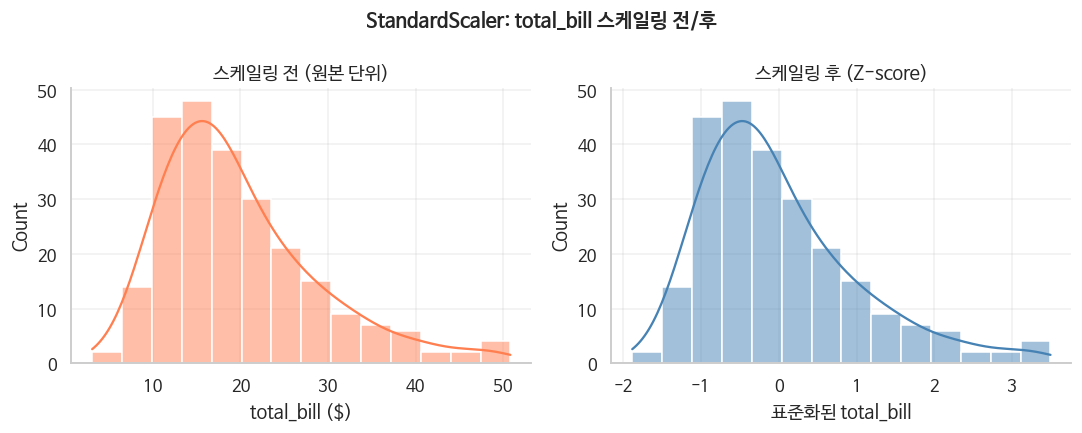

In [ ]:
# ── 스케일링: StandardScaler ──────────────────────────────────────────────
# StandardScaler: 평균=0, 표준편차=1 로 변환 → Z-score 정규화
# 거리 기반 알고리즘(KNN, SVM 등)에서 필수적
# 트리 모델 기반 알고리즘에서는 필수 X - 하지만 트리 모델만 쓰는 건 아니므로 관례적으로 스케일링 함

# [회귀] 스케일링 대상 컬럼
# total_bill_clean은 df_tips_fe에 없으므로 실제 존재하는 컬럼만 지정
scale_cols_tips = ['total_bill', 'size']

scaler_tips = StandardScaler()
# fit_transform(): 평균/표준편차를 학습하고 동시에 변환
df_tips_scaled = df_tips_fe.copy()
df_tips_scaled[scale_cols_tips] = scaler_tips.fit_transform(
    df_tips_scaled[scale_cols_tips]
)

print("▶ [회귀] StandardScaler 적용 완료")
print(f"  total_bill 스케일링 전 - 평균: {df_tips_fe['total_bill'].mean():.2f}, 표준편차: {df_tips_fe['total_bill'].std():.2f}")
print(f"  total_bill 스케일링 후 - 평균: {df_tips_scaled['total_bill'].mean():.4f}, 표준편차: {df_tips_scaled['total_bill'].std():.4f}")

# ── 스케일링 전후 비교 시각화 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('StandardScaler: total_bill 스케일링 전/후', fontsize=13, fontweight='bold')

sns.histplot(df_tips_fe['total_bill'], kde=True, ax=axes[0], color='coral')
axes[0].set_title('스케일링 전 (원본 단위)')
axes[0].set_xlabel('total_bill ($)')

sns.histplot(df_tips_scaled['total_bill'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('스케일링 후 (Z-score)')
axes[1].set_xlabel('표준화된 total_bill')

plt.tight_layout()
plt.show()

---
## 6. 상관관계 분석

**상관관계(Correlation)**: 두 변수 간의 관계를 나타내는 통계적 개념

$$-1 \leq r \leq 1$$

| 범위 | 의미 |
|------|------|
| $r = 1$ | 완전한 양의 상관관계 |
| $r = 0$ | 독립 (관계 없음) |
| $r = -1$ | 완전한 음의 상관관계 |

### 상관관계 분석 목적
- 데이터 간의 상관관계를 시각화하여 분석
- 결과를 바탕으로 **머신러닝 모델 선택의 방향** 제시
- 중복되는 특성(다중공선성) 발견 및 제거

### 시각화 방법
- **pairplot**: 변수 간 산점도 출력 (수치형 변수 전체)
- **heatmap**: 피어슨 상관계수를 사용하여 변수 간 상관관계 시각화


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# [회귀] tips 상관관계 분석
# ══════════════════════════════════════════════════════════════════════════════

# 수치형 변수만 선택 (더미 변수 포함)
numeric_tips = df_tips_fe.select_dtypes(include=[np.number])

# .corr(method='pearson'): 피어슨 상관계수 행렬 계산
# 피어슨: 두 변수의 선형 관계 강도를 측정 (-1 ~ 1)
pearson_tips = numeric_tips.corr(method='pearson')

print("[회귀] tips 피어슨 상관계수 행렬:")
display(pearson_tips[['tip']].sort_values('tip', ascending=False).round(3))


[회귀] tips 피어슨 상관계수 행렬:


,tip
tip,1.000
total_bill,0.676
total_bill_clean,0.658
size,0.489
tip_rate,0.342
day_Sun,0.125
time_Dinner,0.122
day_Sat,-0.003
smoker_No,-0.006
day_Fri,-0.055


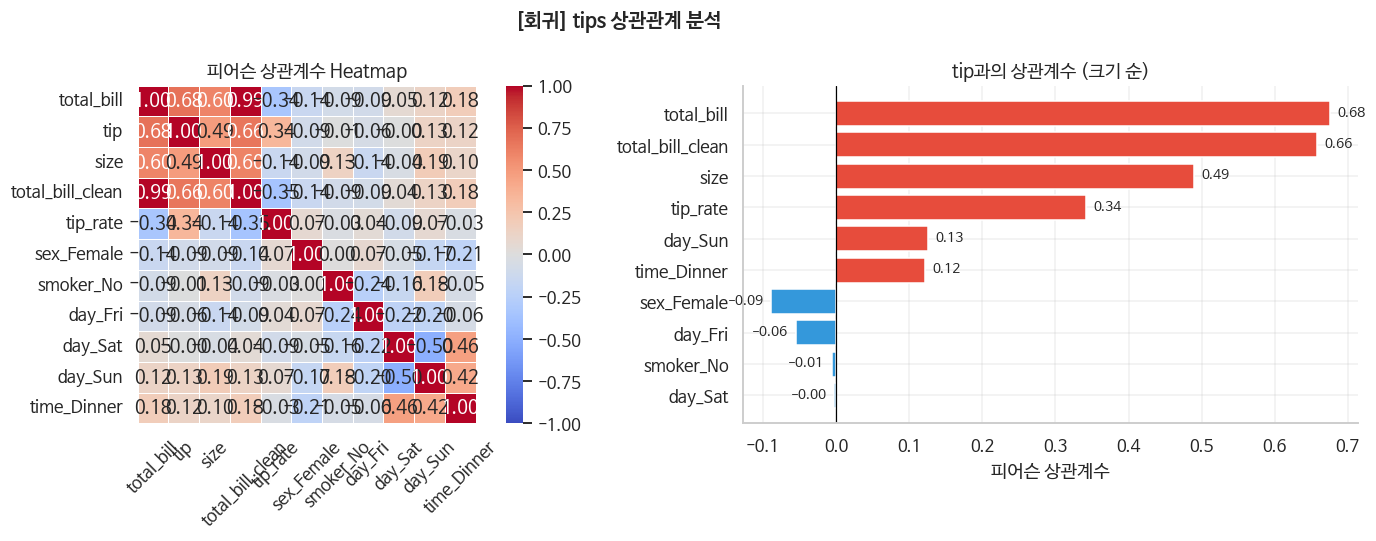

In [ ]:
# ── 상관관계 시각화 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('[회귀] tips 상관관계 분석', fontsize=13, fontweight='bold')

# ── 1) Heatmap: 상관계수 행렬 시각화 ─────────────────────────────────────
# annot=True: 각 셀에 수치 표시
# fmt='.2f': 소수점 2자리 표시
# cmap: 색상 팔레트 ('coolwarm': 음수=파랑, 양수=빨강)
# vmin/vmax: 색상 범위 고정 (-1 ~ 1)
sns.heatmap(
    pearson_tips,
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    square=True, ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('피어슨 상관계수 Heatmap')
axes[0].tick_params(axis='x', rotation=45)

# ── 2) 목표 변수(tip)와의 상관관계 막대 그래프 ────────────────────────────
# tip과의 상관계수를 절댓값 기준으로 정렬
tip_corr = pearson_tips['tip'].drop('tip').sort_values(key=abs, ascending=True)

colors = ['#e74c3c' if v > 0 else '#3498db' for v in tip_corr.values]
axes[1].barh(tip_corr.index, tip_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('tip과의 상관계수 (크기 순)')
axes[1].set_xlabel('피어슨 상관계수')
# 각 막대 끝에 수치 표시
for i, (idx, v) in enumerate(tip_corr.items()):
 axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i,
 f'{v:.2f}', va='center',
 ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


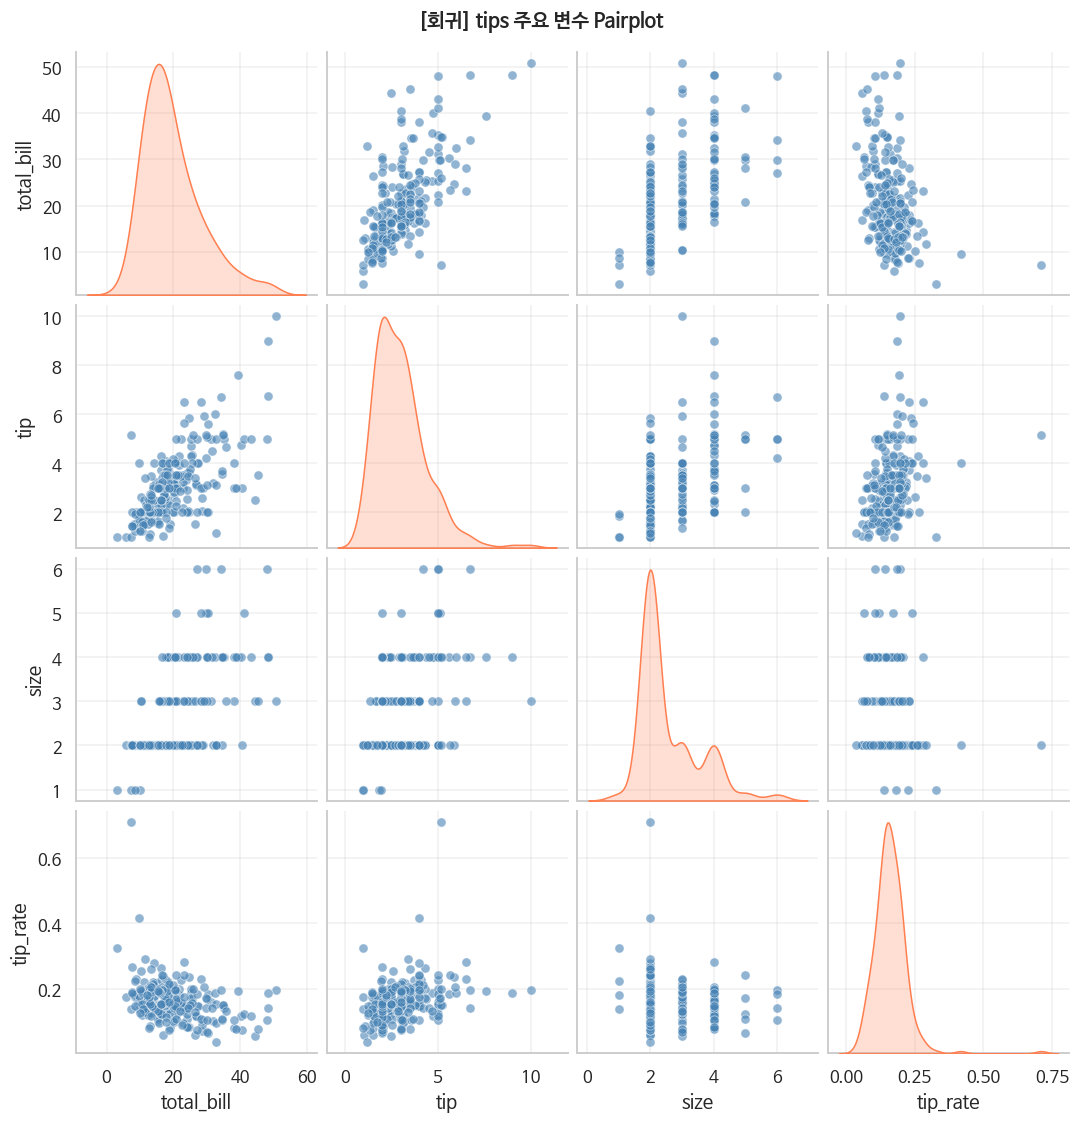

In [ ]:
# ── Pairplot: 변수 간 산점도 행렬 ────────────────────────────────────────
# 수치형 핵심 변수만 선택 (가독성을 위해 일부만)
pairplot_cols = ['total_bill', 'tip', 'size', 'tip_rate']

fig = sns.pairplot(
    df_tips_fe[pairplot_cols],
    diag_kind='kde',       # 대각선: 각 변수의 분포(KDE)
    plot_kws={'alpha': 0.6, 'color': 'steelblue'},
    diag_kws={'color': 'coral'}
)
fig.figure.suptitle('[회귀] tips 주요 변수 Pairplot', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 7. 모델 학습 및 평가

### 데이터 분리 (train_test_split)

전체 데이터세트를 **훈련 세트**와 **테스트 세트**로 나누는 과정

- 전체 데이터로 학습 후 같은 데이터로 평가하면 → **과적합 발생 가능**
- 일반적으로 **7:3 또는 8:2 비율**로 분리

```python
train_test_split(*arrays, test_size, random_state)
```

| 파라미터 | 설명 |
|---------|------|
| `*arrays` | 분리할 데이터 (X, y) |
| `test_size` | 전체 데이터 중 테스트 세트의 비율 |
| `random_state` | 동일한 결과를 위한 난수값(시드) |

### 교차 검증 (K-fold Cross Validation)

과적합을 방지하기 위한 검증 방법

- 데이터를 K개 폴드로 나누어 K번 학습·검증 반복
- 학습 데이터를 고정된 형태로 사용하지 않도록 변화시키는 방법

### 평가 지표

| 유형 | 지표 | 설명 |
|------|------|------|
| **회귀** | R² (결정계수) | 1에 가까울수록 좋음 |
| **회귀** | RMSE | 낮을수록 좋음 |
| **분류** | Accuracy | 전체 중 맞춘 비율 |
| **분류** | F1-score | 정밀도·재현율의 조화 평균 |


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# [회귀] tips 데이터셋으로 팁 금액 예측
# ══════════════════════════════════════════════════════════════════════════════

# ── 특성(X)과 목표변수(y) 분리 ────────────────────────────────────────────
# 목표변수: tip (팁 금액)
# 특성: tip을 제외한 나머지 수치형 컬럼

print(f"[회귀] 특성 변수 목록: {list(X_tips.columns)}")
print(f"특성(X) 크기: {X_tips.shape}")
print(f"목표(y) 크기: {y_tips.shape}")

# ── 데이터 분리: 훈련 세트(70%) / 테스트 세트(30%) ─────────────────────────
print(f"\n훈련 세트: {X_train.shape[0]}건")
print(f"테스트 세트: {X_test.shape[0]}건")


[회귀] 특성 변수 목록: ['total_bill', 'size', 'sex_Female', 'smoker_No', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Dinner']
특성(X) 크기: (244, 8)
목표(y) 크기: (244,)

훈련 세트: 170건
테스트 세트: 74건


In [ ]:
# ── 모델 학습 및 예측 ─────────────────────────────────────────────────────
# ── 1) 선형 회귀 (Linear Regression) ─────────────────────────────────────

# ── 2) 랜덤 포레스트 회귀 (Random Forest Regressor) ──────────────────────

# ── 평가: R²와 RMSE 계산 ─────────────────────────────────────────────────
print("=" * 50)
print("[회귀] 모델 성능 비교")
print("=" * 50)

print(f"\n [{name}]")
print(f" R² : {r2:.4f} (1에 가까울수록 좋음)")
print(f" RMSE : {rmse:.4f} (낮을수록 좋음)")


[회귀] 모델 성능 비교

 [선형 회귀]
 R² : 0.2931 (1에 가까울수록 좋음)
 RMSE : 0.9653 (낮을수록 좋음)

 [랜덤 포레스트]
 R² : 0.2815 (1에 가까울수록 좋음)
 RMSE : 0.9732 (낮을수록 좋음)


In [ ]:
# ── 교차 검증 (K-fold Cross Validation) ──────────────────────────────────
# KFold: 데이터를 K개 폴드로 나눠 K번 반복 학습/검증

# cross_val_score(): 교차 검증 자동 수행 → 각 fold의 점수 반환

print("=" * 50)
print("[회귀] 5-Fold 교차 검증 결과")
print("=" * 50)
print(f"\n선형 회귀 - 각 Fold R²: {cv_scores_lr.round(3)}")
print(f" 평균 R²: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"\n랜덤 포레스트 - 각 Fold R²: {cv_scores_rf.round(3)}")
print(f" 평균 R²: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")


[회귀] 5-Fold 교차 검증 결과

선형 회귀 - 각 Fold R²: [0.437 0.092 0.561 0.501 0.324]
 평균 R²: 0.3831 ± 0.1653

랜덤 포레스트 - 각 Fold R²: [0.303 0.135 0.638 0.572 0.423]
 평균 R²: 0.4143 ± 0.1819


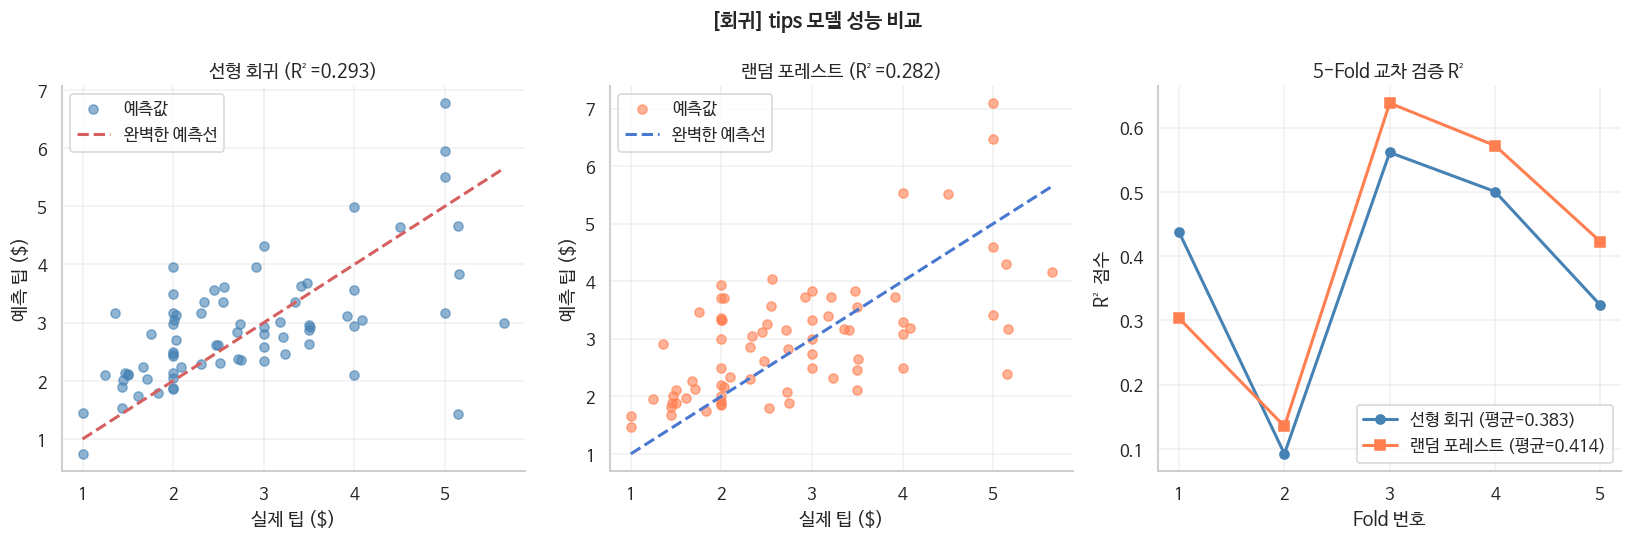

In [ ]:
# ── 회귀 결과 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('[회귀] tips 모델 성능 비교', fontsize=13, fontweight='bold')

# 1) 실제값 vs 예측값 산점도 (선형 회귀)
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', label='예측값')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
 'r--', lw=2, label='완벽한 예측선') # y=x 대각선
axes[0].set_xlabel('실제 팁 ($)')
axes[0].set_ylabel('예측 팁 ($)')
axes[0].set_title(f'선형 회귀 (R²={r2_score(y_test, y_pred_lr):.3f})')
axes[0].legend()

# 2) 실제값 vs 예측값 산점도 (랜덤 포레스트)
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='coral', label='예측값')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
 'b--', lw=2, label='완벽한 예측선')
axes[1].set_xlabel('실제 팁 ($)')
axes[1].set_ylabel('예측 팁 ($)')
axes[1].set_title(f'랜덤 포레스트 (R²={r2_score(y_test, y_pred_rf):.3f})')
axes[1].legend()

# 3) 교차 검증 점수 비교
x_cv = np.arange(1, 6) # Fold 번호
axes[2].plot(x_cv, cv_scores_lr, 'o-', color='steelblue',
 label=f'선형 회귀 (평균={cv_scores_lr.mean():.3f})', linewidth=2)
axes[2].plot(x_cv, cv_scores_rf, 's-', color='coral',
 label=f'랜덤 포레스트 (평균={cv_scores_rf.mean():.3f})', linewidth=2)
axes[2].set_xlabel('Fold 번호')
axes[2].set_ylabel('R² 점수')
axes[2].set_title('5-Fold 교차 검증 R²')
axes[2].set_xticks(x_cv)
axes[2].legend()

plt.tight_layout()
plt.show()


---
### [분류] titanic 데이터셋으로 생존 여부 예측


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# [분류] titanic 데이터셋으로 생존 여부 예측
# ══════════════════════════════════════════════════════════════════════════════

# ── 특성(X)과 목표변수(y) 분리 ────────────────────────────────────────────
# 목표변수: survived (생존 여부: 0=사망, 1=생존)

# 수치형 컬럼만 선택 (범주형 컬럼은 이미 더미 변환됨)

print(f"[분류] 특성 변수 목록: {list(X_titanic.columns)}")
print(f"특성(X) 크기: {X_titanic.shape}")
print(f"목표(y) 크기: {y_titanic.shape}")
print(f"\n생존 비율: {y_titanic.value_counts(normalize=True).round(3).to_dict()}")

# ── 데이터 분리 ────────────────────────────────────────────────────────────
print(f"\n훈련 세트: {X_tr.shape[0]}건")
print(f"테스트 세트: {X_te.shape[0]}건")


[분류] 특성 변수 목록: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S', 'age_group_청소년', 'age_group_청년', 'age_group_중년', 'age_group_노인']
특성(X) 크기: (889, 12)
목표(y) 크기: (889,)

생존 비율: {0: 0.618, 1: 0.382}

훈련 세트: 622건
테스트 세트: 267건


In [ ]:
# ── 스케일링: 분류 모델에도 스케일링 적용 ─────────────────────────────────
# 로지스틱 회귀는 스케일에 민감하므로 StandardScaler 적용
# 주의: 테스트 데이터에 fit하면 데이터 누수(data leakage) 발생

# ── 모델 학습 ─────────────────────────────────────────────────────────────
# 1) 로지스틱 회귀 (Logistic Regression)

# 2) 랜덤 포레스트 분류기 (Random Forest Classifier)

# ── 평가 ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("[분류] 모델 성능 비교")
print("=" * 60)

print(f"\n [{name}]")
print(f" 정확도(Accuracy): {acc:.4f}")
print(f"\n 분류 리포트:")
print(classification_report(y_te, y_pred, target_names=['사망(0)', '생존(1)']))
print("-" * 40)


[분류] 모델 성능 비교

 [로지스틱 회귀]
 정확도(Accuracy): 0.7903

 분류 리포트:
 precision recall f1-score support

 사망(0) 0.81 0.86 0.84 165
 생존(1) 0.75 0.68 0.71 102

 accuracy 0.79 267
 macro avg 0.78 0.77 0.77 267
weighted avg 0.79 0.79 0.79 267

----------------------------------------

 [랜덤 포레스트]
 정확도(Accuracy): 0.8315

 분류 리포트:
 precision recall f1-score support

 사망(0) 0.84 0.89 0.87 165
 생존(1) 0.81 0.74 0.77 102

 accuracy 0.83 267
 macro avg 0.83 0.81 0.82 267
weighted avg 0.83 0.83 0.83 267

----------------------------------------


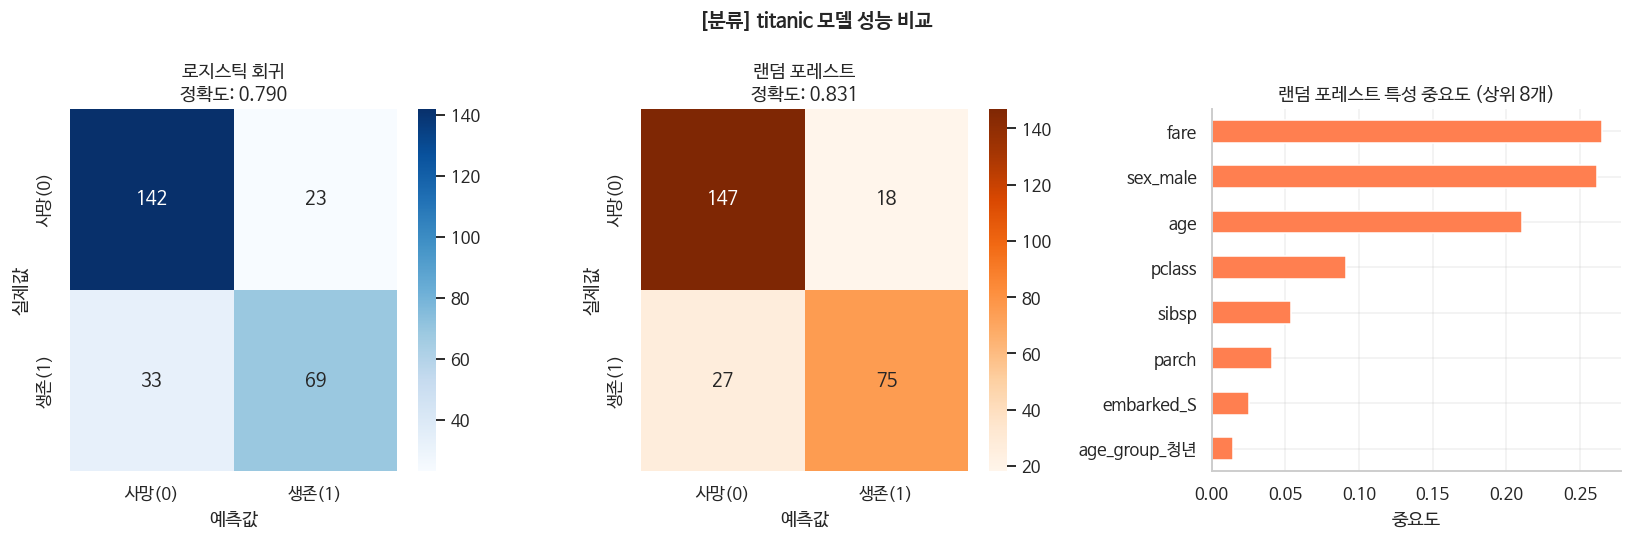


 특성 중요도: 모델이 예측할 때 각 변수를 얼마나 많이 활용했는지를 나타냄
 → 중요도가 높은 변수일수록 생존 예측에 더 큰 영향을 미침


In [ ]:
# ── 분류 결과 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('[분류] titanic 모델 성능 비교', fontsize=13, fontweight='bold')

# 1) 혼동 행렬 (Confusion Matrix) - 로지스틱 회귀
axes[0].set_title(f'로지스틱 회귀\n정확도: {accuracy_score(y_te, y_pred_log):.3f}')
axes[0].set_ylabel('실제값')
axes[0].set_xlabel('예측값')

# 2) 혼동 행렬 - 랜덤 포레스트
axes[1].set_title(f'랜덤 포레스트\n정확도: {accuracy_score(y_te, y_pred_rf_cls):.3f}')
axes[1].set_ylabel('실제값')
axes[1].set_xlabel('예측값')

# 3) 랜덤 포레스트 특성 중요도 (Feature Importance)

axes[2].set_title('랜덤 포레스트 특성 중요도 (상위 8개)')
axes[2].set_xlabel('중요도')

plt.tight_layout()
plt.show()

print("\n 특성 중요도: 모델이 예측할 때 각 변수를 얼마나 많이 활용했는지를 나타냄")
print(" → 중요도가 높은 변수일수록 생존 예측에 더 큰 영향을 미침")


---
## 정리

| 단계 | 주요 작업 | 사용 함수/클래스 |
|------|---------|----------------|
| **EDA** | 데이터 확인 및 분포 파악 | `.info()`, `.describe()`, `sns.histplot()` |
| **결측치 처리** | 삭제 / 대체 | `.drop()`, `.dropna()`, `.fillna()` |
| **이상치 처리** | IQR 기반 탐지 및 대체 | `.quantile()`, `.clip()`, `sns.boxplot()` |
| **특성 엔지니어링** | 변수 생성, 바이닝, 더미, 스케일링 | `pd.cut()`, `pd.get_dummies()`, `StandardScaler` |
| **상관관계 분석** | 변수 간 관계 파악 | `.corr()`, `sns.heatmap()`, `sns.pairplot()` |
| **모델 학습** | 회귀/분류 모델 학습 | `LinearRegression`, `RandomForestRegressor/Classifier` |
| **모델 평가** | 성능 측정 및 과적합 방지 | `train_test_split`, `cross_val_score`, `confusion_matrix` |

> **다음 단계**: Pipeline을 활용한 전처리-모델 통합 관리
